# Проект. Виртуальный коуч
В этом проекте мы создаем виртуального коуча, способного анализировать действия человека на видео с помощью распознавания действия по ключевым точкам, обнаруженным на теле человека.



#**Sprint III** посвящён сравнению движений на видео и решает задачу "умеем ли мы анализировать движение человека на видео?"

- Видео разбивается на кадры, для каждого кадра определяется поза человека, после чего движения пользователя сравниваются с референсным видео с помощью аффинного выравнивания, косинусного сходства и взвешенной дистанции. Итогом становится оценка качества выполнения упражнения.
- Sprint IV объединяет результаты предыдущих этапов в полноценного виртуального коуча, который анализирует видео пользователя, сравнивает его движения с эталоном и выводит оценку сходства и обратную связь.

In [1]:
# зависимости
!pip install opencv-python tqdm pandas matplotlib

In [2]:
# Imports
import os
import cv2
import torch
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from tqdm import tqdm

In [3]:
# создать проект
import os

PROJECT_DIR = "/content/Virtual_Coach"

folders = [
    "src",
    "data/videos/coach",
    "data/videos/user",
    "results/csv",
    "results/plots",
    "results/frames"
]


for folder in folders:
    os.makedirs(
        os.path.join(PROJECT_DIR, folder),
        exist_ok=True
    )


print("Project created")

Project created


In [4]:
import os


PROJECT_DIR = "/content/Virtual_Coach"


for root, dirs, files in os.walk(PROJECT_DIR):

    level = root.replace(PROJECT_DIR, "").count(os.sep)

    indent = "    " * level

    print(
        indent + os.path.basename(root) + "/"
    )

    subindent = "    " * (level + 1)

    for file in files:
        print(
            subindent + file
        )

Virtual_Coach/
    data/
        videos/
            coach/
            user/
    results/
        plots/
        csv/
        frames/
    src/


In [5]:
# создать пакет src
# Добавить пустой файл:

%%writefile /content/Virtual_Coach/src/__init__.py

Writing /content/Virtual_Coach/src/__init__.py


# создать модули

### создать pose_utils.py

In [6]:
# создать pose_utils.py
%%writefile /content/Virtual_Coach/src/pose_utils.py

import numpy as np
import cv2

COCO_WEIGHTS = np.array([

    0.5,   # nose
    0.3,   # left_eye
    0.3,   # right_eye
    0.3,   # left_ear
    0.3,   # right_ear


    1.0,   # left_shoulder
    1.0,   # right_shoulder


    1.5,   # left_elbow
    1.5,   # right_elbow


    1.8,   # left_wrist
    1.8,   # right_wrist


    2.0,   # left_hip
    2.0,   # right_hip


    2.5,   # left_knee
    2.5,   # right_knee


    3.0,   # left_ankle
    3.0    # right_ankle

])



def normalize_pose(kp):
    """
    Normalize human pose.

    Input:
        kp shape (17,3)

    Output:
        normalized pose
    """

    if kp is None:
        return None


    kp = kp.copy()


    # центр тела - середина бедер
    center = (
        kp[11, :2] +
        kp[12, :2]
    ) / 2


    # переносим тело в центр координат
    kp[:, :2] -= center


    # масштабирование по плечам
    scale = np.linalg.norm(
        kp[5,:2] -
        kp[6,:2]
    )


    if scale == 0:
        return None


    kp[:, :2] /= scale


    return kp



def affine_transform(source, target):

    """
    Align source pose to target pose
    using stable body keypoints
    """

    if source is None or target is None:
        return None


    # стабильные точки тела COCO
    alignment_points = [
        5,6,       # shoulders
        11,12,     # hips
        13,14,     # knees
        15,16      # ankles
    ]


    src = source[
        alignment_points,
        :2
    ].astype(
        np.float32
    )


    dst = target[
        alignment_points,
        :2
    ].astype(
        np.float32
    )


    matrix, _ = cv2.estimateAffinePartial2D(
        src,
        dst
    )


    if matrix is None:
        return None


    # применяем transform ко всем 17 точкам пользователя

    all_points = source[:,:2].astype(
        np.float32
    )


    aligned = cv2.transform(
        np.array([all_points]),
        matrix
    )[0]


    return aligned



def cosine_similarity(a,b):
    """
    Cosine similarity
    """

    if a is None or b is None:
        return 0


    a = a.flatten()
    b = b.flatten()


    denominator = (
        np.linalg.norm(a) *
        np.linalg.norm(b)
    )


    if denominator == 0:
        return 0


    return np.dot(a,b) / denominator



def weighted_distance(
        a,
        b,
        weights=None):


    if a is None or b is None:
        return np.inf


    distances = np.linalg.norm(
        a-b,
        axis=1
    )


    if weights is None:

        weights = COCO_WEIGHTS


    if len(weights) != len(distances):

        raise ValueError(
            "Weights length must match keypoints"
        )


    return np.average(
        distances,
        weights=weights
    )


Writing /content/Virtual_Coach/src/pose_utils.py


### создать video_utils.py

In [7]:
# создать video_utils.py

%%writefile /content/Virtual_Coach/src/video_utils.py

import cv2
import os

def extract_frames(
        video_path,
        save_dir=None,
        max_frames=None):

    """
    Extract frames from video
    """


    cap = cv2.VideoCapture(
        video_path
    )


    fps = cap.get(
        cv2.CAP_PROP_FPS
    )


    frames = []

    frame_id = 0



    while True:

        ret, frame = cap.read()


        if not ret:
            break


        frames.append(frame)



        if save_dir:

            os.makedirs(
                save_dir,
                exist_ok=True
            )


            cv2.imwrite(
                os.path.join(
                    save_dir,
                    f"frame_{frame_id}.jpg"
                ),
                frame
            )



        frame_id += 1



        if max_frames:

            if frame_id >= max_frames:
                break



    cap.release()


    return frames, fps




def create_output_video(
        frames,
        output_path,
        fps):


    height, width, _ = frames[0].shape


    writer = cv2.VideoWriter(
        output_path,
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (width,height)
    )


    for frame in frames:

        writer.write(frame)


    writer.release()

Writing /content/Virtual_Coach/src/video_utils.py


### создать visualization.py

In [8]:
# создать visualization.py

%%writefile /content/Virtual_Coach/src/visualization.py

import cv2



COCO_CONNECTIONS = [

(5,7),
(7,9),

(6,8),
(8,10),

(5,6),

(5,11),
(6,12),

(11,12),

(11,13),
(13,15),

(12,14),
(14,16)

]



def draw_skeleton(
        frame,
        keypoints,
        score=None):


    output = frame.copy()


    # точки

    for x,y,c in keypoints:

        if c > 0.3:

            cv2.circle(
                output,
                (int(x),int(y)),
                5,
                (0,255,0),
                -1
            )


    # линии

    for p1,p2 in COCO_CONNECTIONS:

        x1,y1,c1 = keypoints[p1]
        x2,y2,c2 = keypoints[p2]


        if c1>0.3 and c2>0.3:

            cv2.line(
                output,
                (int(x1),int(y1)),
                (int(x2),int(y2)),
                (255,0,0),
                3
            )


    if score:

        cv2.putText(
            output,
            f"Score: {score:.1f}%",
            (30,50),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.5,
            (0,0,255),
            3
        )


    return output

Writing /content/Virtual_Coach/src/visualization.py


In [9]:
# создать пакет Python

!touch /content/Virtual_Coach/src/__init__.py

In [10]:
# Проверить, что всё создано
import os

print(
    os.listdir(
        "/content/Virtual_Coach/src"
    )
)

['pose_utils.py', 'visualization.py', 'video_utils.py', '__init__.py']


In [11]:
# теперь импорт:
import sys

sys.path.append(
    "/content/Virtual_Coach"
)


from src.pose_utils import (
    normalize_pose,
    affine_transform,
    cosine_similarity,
    weighted_distance,
    COCO_WEIGHTS
)


from src.video_utils import (
    extract_frames,
    create_output_video
)


from src.visualization import (
    draw_skeleton
)


print("All modules imported")

All modules imported


In [12]:
# первый импорт
import sys

sys.path.append(
    "/content/Virtual_Coach"
)


from src.pose_utils import (
    normalize_pose,
    affine_transform,
    cosine_similarity,
    weighted_distance,
    COCO_WEIGHTS
)


print("pose_utils loaded")

pose_utils loaded


In [13]:
# проверка
print(
    len(COCO_WEIGHTS)
)

17


# загрузка видео

In [14]:
# загрузка coach
from google.colab import files

uploaded = files.upload()

Saving dspr_cv_u1_diploma_spr3_2.mp4 to dspr_cv_u1_diploma_spr3_2.mp4


In [15]:
# Перенос:
import shutil

shutil.move(
    "/content/dspr_cv_u1_diploma_spr3_2.mp4",
    "/content/Virtual_Coach/data/videos/coach/dspr_cv_u1_diploma_spr3_2.mp4"
)

'/content/Virtual_Coach/data/videos/coach/dspr_cv_u1_diploma_spr3_2.mp4'

In [16]:
# загрузка user
from google.colab import files

uploaded = files.upload()

Saving my_motion.mp4.MOV to my_motion.mp4.MOV


In [17]:
# Перенос:
import shutil

shutil.move(
    "/content/my_motion.mp4.MOV",
    "/content/Virtual_Coach/data/videos/user/my_motion.mp4.MOV"
)

'/content/Virtual_Coach/data/videos/user/my_motion.mp4.MOV'

In [18]:
import os


for root, dirs, files in os.walk("/content/Virtual_Coach"):

    print(root)
    for f in files:
        print("   ", f)

/content/Virtual_Coach
/content/Virtual_Coach/data
/content/Virtual_Coach/data/videos
/content/Virtual_Coach/data/videos/coach
    dspr_cv_u1_diploma_spr3_2.mp4
/content/Virtual_Coach/data/videos/user
    my_motion.mp4.MOV
/content/Virtual_Coach/results
/content/Virtual_Coach/results/plots
/content/Virtual_Coach/results/csv
/content/Virtual_Coach/results/frames
/content/Virtual_Coach/src
    pose_utils.py
    visualization.py
    video_utils.py
    __init__.py
/content/Virtual_Coach/src/__pycache__
    __init__.cpython-312.pyc
    visualization.cpython-312.pyc
    pose_utils.cpython-312.pyc
    video_utils.cpython-312.pyc


In [19]:
# переименовать видео пользователя
import os


old_path = (
    "/content/Virtual_Coach/"
    "data/videos/user/"
    "my_motion.mp4.MOV"
)


new_path = (
    "/content/Virtual_Coach/"
    "data/videos/user/"
    "my_motion.mp4"
)


os.rename(
    old_path,
    new_path
)


print("Renamed:")
print(new_path)

Renamed:
/content/Virtual_Coach/data/videos/user/my_motion.mp4


In [20]:
# Проверить результат
import os


USER_DIR = "/content/Virtual_Coach/data/videos/user"


print(
    os.listdir(USER_DIR)
)

['my_motion.mp4']


In [21]:
# создаём пути

PROJECT_DIR="/content/Virtual_Coach"


COACH_VIDEO = (
    PROJECT_DIR +
    "/data/videos/coach/"
    "dspr_cv_u1_diploma_spr3_2.mp4"
)


USER_VIDEO = (
    PROJECT_DIR +
    "/data/videos/user/"
    "my_motion.mp4"
)


print("Coach:")
print(COACH_VIDEO)


print("\nUser:")
print(USER_VIDEO)

Coach:
/content/Virtual_Coach/data/videos/coach/dspr_cv_u1_diploma_spr3_2.mp4

User:
/content/Virtual_Coach/data/videos/user/my_motion.mp4


In [22]:
# Проверка, что оба файла доступны
import os


print(
    "Coach exists:",
    os.path.exists(COACH_VIDEO)
)


print(
    "User exists:",
    os.path.exists(USER_VIDEO)
)

Coach exists: True
User exists: True


In [23]:
# проверить параметры видео (Для обоих видео):

import cv2

def check_video(path):

    cap = cv2.VideoCapture(path)


    fps = cap.get(
        cv2.CAP_PROP_FPS
    )


    frames = int(
        cap.get(
            cv2.CAP_PROP_FRAME_COUNT
        )
    )


    width = int(
        cap.get(
            cv2.CAP_PROP_FRAME_WIDTH
        )
    )


    height = int(
        cap.get(
            cv2.CAP_PROP_FRAME_HEIGHT
        )
    )


    cap.release()


    print("File:", path)
    print("FPS:", fps)
    print("Frames:", frames)
    print("Resolution:", width, "x", height)
    print("----------------------")



check_video(
    COACH_VIDEO
)


check_video(
    USER_VIDEO
)

File: /content/Virtual_Coach/data/videos/coach/dspr_cv_u1_diploma_spr3_2.mp4
FPS: 30.0
Frames: 638
Resolution: 406 x 718
----------------------
File: /content/Virtual_Coach/data/videos/user/my_motion.mp4
FPS: 29.65034965034965
Frames: 106
Resolution: 2160 x 3840
----------------------


In [24]:
# Проверить только видеофайлы

import glob

coach_files = glob.glob(
    "/content/Virtual_Coach/data/videos/coach/*"
)


user_files = glob.glob(
    "/content/Virtual_Coach/data/videos/user/*"
)


print("Coach videos:")
for f in coach_files:
    print(f)


print("\nUser videos:")
for f in user_files:
    print(f)

Coach videos:
/content/Virtual_Coach/data/videos/coach/dspr_cv_u1_diploma_spr3_2.mp4

User videos:
/content/Virtual_Coach/data/videos/user/my_motion.mp4


In [25]:
# Проверить размеры файлов
# полезно перед обработкой:

import os

files = [
    COACH_VIDEO,
    USER_VIDEO
]


for file in files:

    size = os.path.getsize(file) / (1024*1024)

    print(
        os.path.basename(file),
        round(size,2),
        "MB"
    )

dspr_cv_u1_diploma_spr3_2.mp4 1.88 MB
my_motion.mp4 10.89 MB


In [26]:
# Пути видео
COACH_VIDEO="/content/Virtual_Coach/data/videos/coach/dspr_cv_u1_diploma_spr3_2.mp4"


USER_VIDEO="/content/Virtual_Coach/data/videos/user/my_motion.mp4"

In [27]:
# Загрузка видео

coach_frames, coach_fps = extract_frames(
    COACH_VIDEO
)


user_frames, user_fps = extract_frames(
    USER_VIDEO
)


print(
    len(coach_frames),
    len(user_frames)
)

638 106


In [28]:
# посмотреть информацию о видео

print("Coach FPS:", coach_fps)
print("User FPS:", user_fps)

print(
    "Coach duration:",
    round(len(coach_frames) / coach_fps, 2),
    "sec"
)

print(
    "User duration:",
    round(len(user_frames) / user_fps, 2),
    "sec"
)

Coach FPS: 30.0
User FPS: 29.65034965034965
Coach duration: 21.27 sec
User duration: 3.58 sec


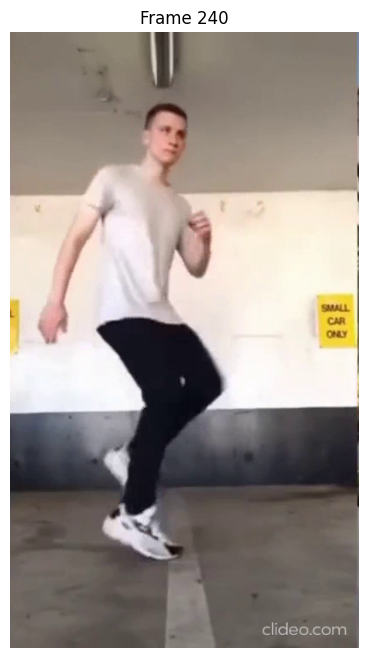

In [29]:
# посмотреть кадры тренера
# нужно выбрать нужное движение

import matplotlib.pyplot as plt
import cv2

frame_id = 240

frame = cv2.cvtColor(
    coach_frames[frame_id],
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(5,8))

plt.imshow(frame)

plt.title(f"Frame {frame_id}")

plt.axis("off")

plt.show()

In [30]:
# выбрать секунды

COACH_START_SEC = 8
COACH_END_SEC = 11

COACH_START = int(
    COACH_START_SEC * coach_fps
)

COACH_END = int(
    COACH_END_SEC * coach_fps
)

print(COACH_START)
print(COACH_END)



240
330


In [31]:
# вырезать нужный кусок
coach_segment_frames = coach_frames[
    COACH_START:COACH_END
]

print(
    "Selected frames:",
    len(coach_segment_frames)
)

Selected frames: 90


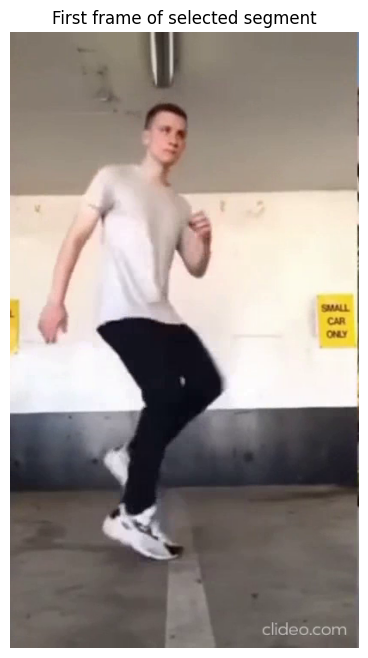

In [32]:
# проверить, что выбрали правильно
frame = cv2.cvtColor(
    coach_segment_frames[0],
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(5,8))

plt.imshow(frame)

plt.title("First frame of selected segment")

plt.axis("off")

plt.show()

In [33]:
# Проверяем путь к видео
USER_VIDEO = "/content/Virtual_Coach/data/videos/user/my_motion.mp4"

#Проверяем:

import os

print(os.path.exists(USER_VIDEO))

True


In [34]:
# извлекаем кадры
# Если используем наш модуль:

from src.video_utils import extract_frames


user_frames, user_fps = extract_frames(
    USER_VIDEO
)


print("User frames:", len(user_frames))
print("FPS:", user_fps)

User frames: 106
FPS: 29.65034965034965


In [35]:
import cv2
def resize_frame(
        frame,
        width=406,
        height=718):

    return cv2.resize(
        frame,
        (width,height),
        interpolation=cv2.INTER_AREA
    )

In [36]:
user_frames_resized = [

    resize_frame(frame)

    for frame in user_frames

]


print(
    len(user_frames_resized)
)

106


In [37]:
# Проверяем размер кадра
# До:

user_frames[0].shape

(3840, 2160, 3)

In [38]:
# Проверяем размер кадра
# После:

user_frames_resized[0].shape

(718, 406, 3)

In [39]:
# Keypoint R-CNN
import torch
import torchvision

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


model = torchvision.models.detection.keypointrcnn_resnet50_fpn(
    weights="DEFAULT"
)


model.to(device)


model.eval()


print(
    "Device:",
    device
)

Downloading: "https://download.pytorch.org/models/keypointrcnn_resnet50_fpn_coco-fc266e95.pth" to /root/.cache/torch/hub/checkpoints/keypointrcnn_resnet50_fpn_coco-fc266e95.pth


100%|██████████| 226M/226M [00:01<00:00, 184MB/s]


Device: cuda


In [40]:
# Создать transform
import torchvision.transforms as T


transform = T.Compose([
    T.ToTensor()
])

In [41]:
# Создать функцию predict_pose()

def predict_pose(frame):

    img = transform(
        frame
    ).to(device)


    with torch.no_grad():

        output = model(
            [img]
        )


    keypoints = output[0]["keypoints"]

    scores = output[0]["scores"]


    # человек не найден

    if len(scores)==0:

        return None


    # выбираем человека с максимальным confidence

    person = torch.argmax(
        scores
    )


    pose = (
        keypoints[person]
        .cpu()
        .numpy()
    )


    return pose

In [42]:
# Проверяем одну картинку

test_pose = predict_pose(
    coach_frames[0]
)

print(test_pose.shape)

(17, 3)


In [43]:
# Теперь запускаем extract_pose_video()

from tqdm import tqdm

def extract_pose_video(frames):

    poses=[]


    for frame in tqdm(frames):

        kp=predict_pose(frame)

        poses.append(kp)


    return poses

In [44]:
# Запуск:
# Извлекаем позы только для выбранного фрагмента тренера

coach_segment_poses = extract_pose_video(
    coach_segment_frames
)

# Извлекаем позы пользователя

user_poses = extract_pose_video(
    user_frames_resized
)

100%|██████████| 106/106 [00:14<00:00,  7.29it/s]


In [45]:
print(
    "Coach segment poses:",
    len(coach_segment_poses)
)

print(
    "User poses:",
    len(user_poses)
)

Coach segment poses: 90
User poses: 106


In [46]:
# Добавим синхронизацию кадров
# Количество кадров для сравнения

min_frames = min(
    len(coach_segment_poses),
    len(user_poses)
)

print(
    "Frames for comparison:",
    min_frames
)

Frames for comparison: 90


In [47]:
# метрики
# Теперь цикл должен быть не через все 638 кадров, а через min_frames

scores=[]

for i in tqdm(range(min_frames)):


    coach_pose = normalize_pose(
        coach_segment_poses[i]
    )


    user_pose = normalize_pose(
        user_poses[i]
    )


    # если поза не найдена

    if coach_pose is None or user_pose is None:

        scores.append({

            "frame": i,
            "similarity": 0,
            "distance": 999,
            "score": 0

        })

        continue



    # проверка количества keypoints

    if (
        coach_pose.shape != (17,3)
        or
        user_pose.shape != (17,3)
    ):

        scores.append({

            "frame": i,
            "similarity":0,
            "distance":999,
            "score":0

        })

        continue



    # affine alignment

    aligned_user_pose = affine_transform(
        user_pose,
        coach_pose
    )


    if aligned_user_pose is None:

        scores.append({

            "frame": i,
            "similarity":0,
            "distance":999,
            "score":0

        })

        continue



    # cosine similarity

    similarity = cosine_similarity(
        coach_pose[:,:2],
        aligned_user_pose
    )


    # weighted distance

    distance = weighted_distance(
        coach_pose[:,:2],
        aligned_user_pose
    )


    # final score

    final_score = (

        0.7 * ((similarity + 1) / 2)

        +

        0.3 * (1/(1+distance))

    ) * 100



    scores.append({

        "frame": i,
        "similarity": similarity,
        "distance": distance,
        "score": final_score

    })

100%|██████████| 90/90 [00:00<00:00, 2481.09it/s]


In [48]:
# функция объединения кадров

import cv2
import numpy as np


def create_comparison_frame(
        coach_frame,
        user_frame,
        coach_pose,
        user_pose,
        score
):

    # рисуем скелет тренера

    if coach_pose is not None:

        coach_frame = draw_skeleton(
            coach_frame,
            coach_pose
        )


    # рисуем скелет пользователя + score

    if user_pose is not None:

        user_frame = draw_skeleton(
            user_frame,
            user_pose,
            score
        )


    # приводим размеры

    height = 718
    width = 406


    coach_frame = cv2.resize(
        coach_frame,
        (width,height)
    )


    user_frame = cv2.resize(
        user_frame,
        (width,height)
    )


    # соединяем горизонтально

    combined = np.hstack(
        [
            coach_frame,
            user_frame
        ]
    )


    return combined

In [49]:
# создать сравнительные кадры

comparison_frames = []


for i in tqdm(range(min_frames)):


    coach_frame = coach_segment_frames[i].copy()

    user_frame = user_frames_resized[i].copy()


    coach_pose = coach_segment_poses[i]

    user_pose = user_poses[i]


    score = scores[i]["score"]



    frame = create_comparison_frame(
        coach_frame,
        user_frame,
        coach_pose,
        user_pose,
        score
    )


    comparison_frames.append(frame)



print(
    "Comparison frames:",
    len(comparison_frames)
)

100%|██████████| 90/90 [00:00<00:00, 775.88it/s]

Comparison frames: 90


**Вывод**: ожидаемый результат,

Comparison frames: 90

In [50]:
# Создаем:

COMPARISON_VIDEO = (
    "/content/Virtual_Coach/results/"
    "coach_user_comparison.mp4"
)


create_output_video(
    comparison_frames,
    COMPARISON_VIDEO,
    user_fps
)


print(
    COMPARISON_VIDEO
)

/content/Virtual_Coach/results/coach_user_comparison.mp4


In [51]:
# Проверить, создался ли файл
import os

print(COMPARISON_VIDEO)

print(
    os.path.exists(COMPARISON_VIDEO)
)

print(
    os.path.getsize(COMPARISON_VIDEO)/(1024*1024),
    "MB"
)

/content/Virtual_Coach/results/coach_user_comparison.mp4
True
2.96085262298584 MB


In [52]:
# Проверить количество кадров

print(
    len(comparison_frames)
)

print(
    comparison_frames[0].shape
)

90
(718, 812, 3)


In [53]:
# Пересоздать видео с правильным кодеком

# проблема с кодеком mp4v.

FIXED_COMPARISON_VIDEO = (
    "/content/Virtual_Coach/results/"
    "coach_user_comparison_fixed.mp4"
)


!ffmpeg -y -i "{COMPARISON_VIDEO}" \
-c:v libx264 \
-pix_fmt yuv420p \
"{FIXED_COMPARISON_VIDEO}"

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [54]:
# Открыть исправленное видео
from IPython.display import Video

Video(
    FIXED_COMPARISON_VIDEO,
    embed=True,
    width=900
)

In [55]:
# Создаем DataFrame

df = pd.DataFrame(scores)


df.head()

,frame,similarity,distance,score
0,0,0.923312,0.641639,85.590322
1,1,0.924168,0.669136,85.319265
2,2,0.927090,0.611180,86.068045
3,3,0.943825,0.493601,88.119564
4,4,0.952597,0.497103,88.379596


In [56]:
# добавить таблицу худших движений
# для тренера это полезнее среднего score:

df.sort_values(
    "score"
).head(10)

,frame,similarity,distance,score
29,29,0.838960,1.086585,78.741169
89,89,0.833833,1.058570,78.757377
36,36,0.849941,1.074947,79.206133
28,28,0.855366,1.023873,79.760884
31,31,0.854048,1.004547,79.857671
37,37,0.858940,1.022805,79.893784
38,38,0.863130,1.001042,80.201732
30,30,0.864965,0.998402,80.285765
80,80,0.842047,0.889757,80.346709
34,34,0.849399,0.920485,80.350012


In [57]:
# сохранить полный отчет Sprint 3/4
REPORT_PATH = (
"/content/Virtual_Coach/results/"
"final_report.csv"
)


df.to_csv(
    REPORT_PATH,
    index=False
)


print(
    "Saved:",
    REPORT_PATH
)

Saved: /content/Virtual_Coach/results/final_report.csv


In [58]:
# сохранить CSV
# после DataFrame:

CSV_PATH = (
"/content/Virtual_Coach/results/csv/frame_scores.csv"
)


df.to_csv(
    CSV_PATH,
    index=False
)


print(
    "Saved:",
    CSV_PATH
)

Saved: /content/Virtual_Coach/results/csv/frame_scores.csv


In [59]:
# Проверка CSV
import os


print(
    os.path.exists(CSV_PATH)
)

True


### Анализ результатов



In [60]:
# Посмотреть статистику

print(df.describe())

           frame  similarity   distance      score
count  90.000000   90.000000  90.000000  90.000000
mean   44.500000    0.909916   0.712460  84.500152
std    26.124701    0.031379   0.153574   2.528213
min     0.000000    0.833833   0.395042  78.741169
25%    22.250000    0.895185   0.590335  83.086691
50%    44.500000    0.919076   0.682896  85.142719
75%    66.750000    0.932353   0.799830  86.318652
max    89.000000    0.965141   1.086585  90.284661


In [61]:
average_score = df["score"].mean()

print(
    f"Average score: {average_score:.2f}%"
)

Average score: 84.50%


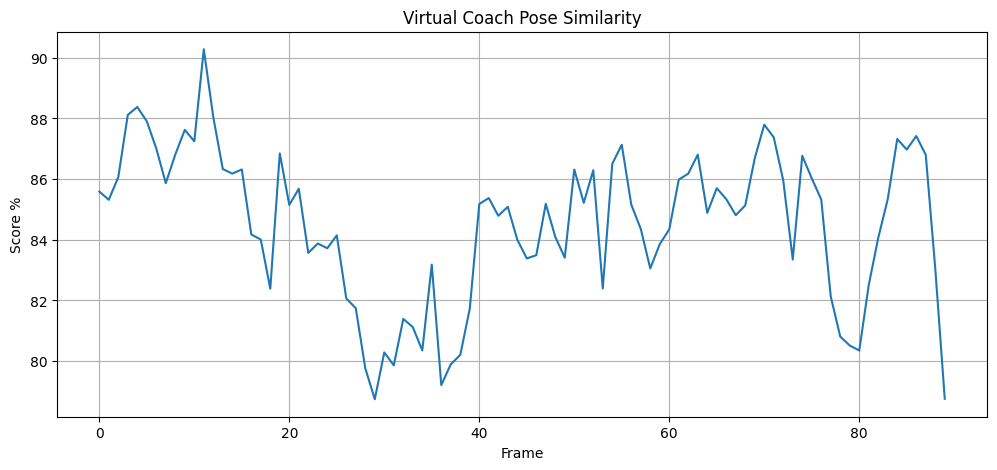

In [62]:
# График

plt.figure(figsize=(12,5))


plt.plot(
    df["frame"],
    df["score"]
)


plt.xlabel("Frame")

plt.ylabel("Score %")

plt.title(
    "Virtual Coach Pose Similarity"
)


plt.grid(True)


plt.show()

In [63]:
# Сохранить график

plot_path = (
"/content/Virtual_Coach/results/plots/"
"pose_score.png"
)


plt.figure(figsize=(12,5))


plt.plot(
    df["frame"],
    df["score"]
)


plt.savefig(
    plot_path
)


plt.close()


print(plot_path)

/content/Virtual_Coach/results/plots/pose_score.png


In [64]:
# Отчет Sprint 3

feedback_path = (
"/content/Virtual_Coach/results/feedback.txt"
)


if average_score >= 90:

    feedback="Excellent movement"

elif average_score >=75:

    feedback="Good posture"

else:

    feedback="Need improvement"



with open(
    feedback_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        f"Average score: {average_score:.2f}%\n"
    )

    f.write(
        feedback
    )



print(
    feedback
)

Good posture


In [65]:
# Посмотреть отчет:
with open(
    "/content/Virtual_Coach/results/feedback.txt",
    "r",
    encoding="utf-8"
) as f:

    print(
        f.read()
    )

Average score: 84.50%
Good posture


In [66]:
# Худшие кадры (где движение отличается)
# полезно для Virtual Coach:

df.sort_values(
    "score"
).head(10)

,frame,similarity,distance,score
29,29,0.838960,1.086585,78.741169
89,89,0.833833,1.058570,78.757377
36,36,0.849941,1.074947,79.206133
28,28,0.855366,1.023873,79.760884
31,31,0.854048,1.004547,79.857671
37,37,0.858940,1.022805,79.893784
38,38,0.863130,1.001042,80.201732
30,30,0.864965,0.998402,80.285765
80,80,0.842047,0.889757,80.346709
34,34,0.849399,0.920485,80.350012


In [67]:
# Virtual Coach
# увидеть лучшие кадры:


df.sort_values(
    "score",
    ascending=False
).head(10)

,frame,similarity,distance,score
11,11,0.965141,0.395042,90.284661
4,4,0.952597,0.497103,88.379596
3,3,0.943825,0.493601,88.119564
12,12,0.954139,0.526958,88.041775
5,5,0.950237,0.526794,87.907319
70,70,0.939061,0.505348,87.796073
9,9,0.946128,0.537624,87.625108
86,86,0.939894,0.536494,87.421265
71,71,0.940110,0.540615,87.376586
84,84,0.937932,0.538767,87.323748


In [68]:
# сохранить результаты метрик:
RESULT_PATH = (
"/content/Virtual_Coach/results/csv/"
"summary_metrics.csv"
)


summary = pd.DataFrame({

    "average_score":[average_score],
    "min_score":[df.score.min()],
    "max_score":[df.score.max()],
    "frames":[len(df)]

})


summary.to_csv(
    RESULT_PATH,
    index=False
)


print("Saved:", RESULT_PATH)

Saved: /content/Virtual_Coach/results/csv/summary_metrics.csv
